<a href="https://colab.research.google.com/github/Nquyen264-2005/TH_DEEPLEARNING/blob/main/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:

import pandas as pd
datatitanic = pd.read_csv("https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/titanic_disaster.csv")

<Axes: xlabel='Pclass', ylabel='Age'>

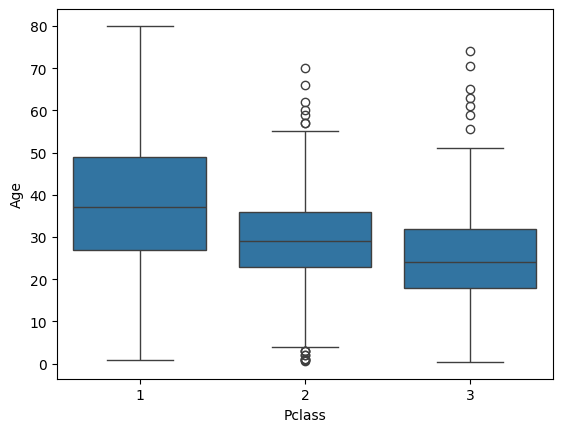

In [4]:

import seaborn as sns
sns.boxplot(y='Age', x='Pclass', data = datatitanic)

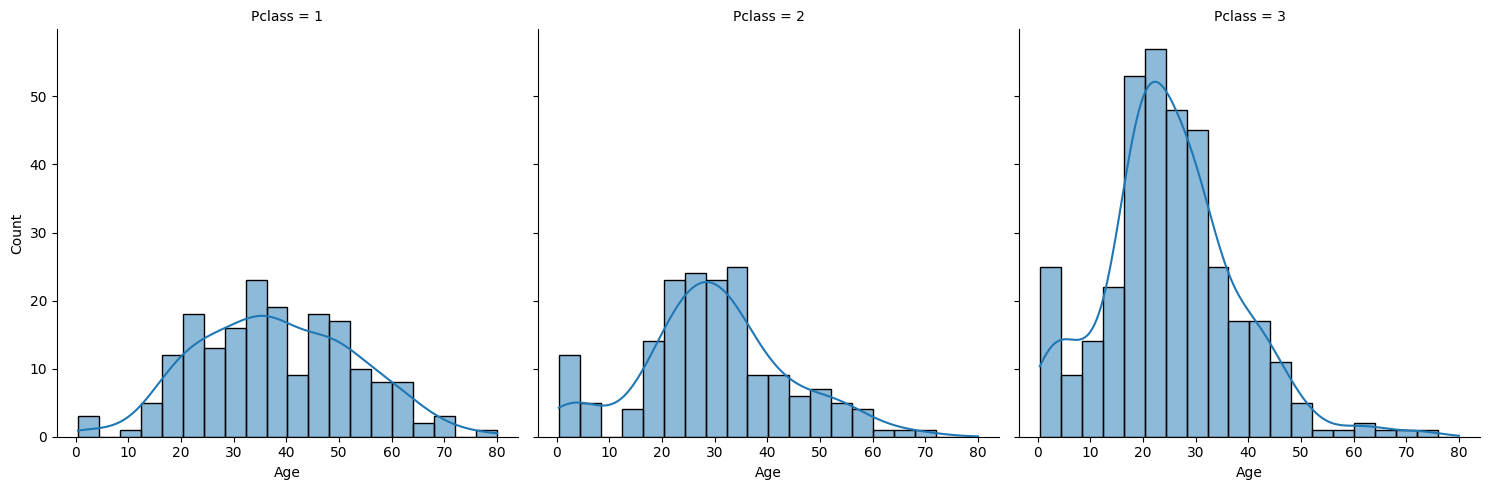

In [5]:
sns.displot(datatitanic, x="Age", col="Pclass", kde=True)

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 6.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 18.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 18.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


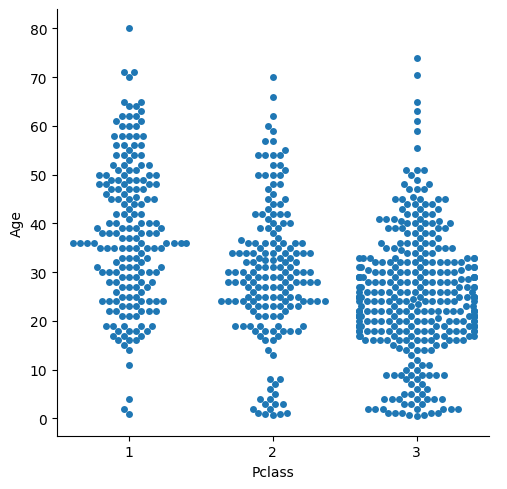

In [6]:

sns.catplot(x="Pclass", y="Age", kind="swarm",data=datatitanic)

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 6.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 18.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 11.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 18.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


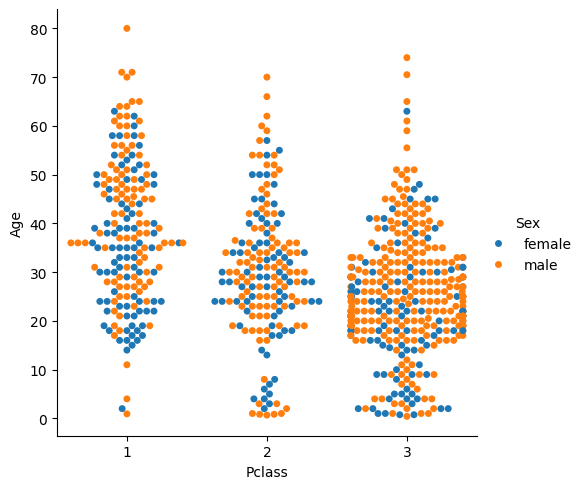

In [7]:
sns.catplot(x="Pclass", y="Age", hue='Sex', kind="swarm",data=datatitanic)

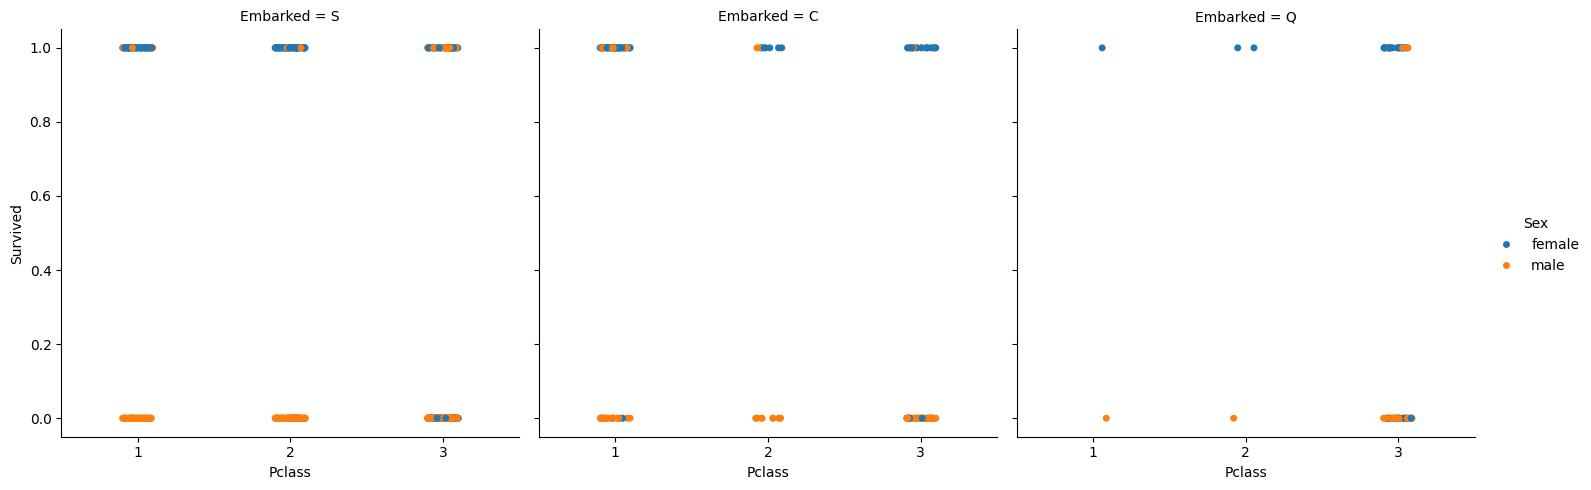

In [10]:
sns.catplot(x='Pclass', y='Survived', hue='Sex', col='Embarked', data=datatitanic)

### Checking for Missing Data

To identify what data information is missing, we can check for null values in each column of the `datatitanic` DataFrame. This will give us a clear picture of which columns have incomplete entries.

In [11]:
# Check for missing values in each column
missing_data = datatitanic.isnull().sum()

# Display columns with missing values and their counts
print("Missing values per column:")
display(missing_data[missing_data > 0])

# Calculate the percentage of missing values
missing_percentage = (datatitanic.isnull().sum() / len(datatitanic)) * 100
print("\nPercentage of missing values per column:")
display(missing_percentage[missing_percentage > 0])

Missing values per column:


,0
Age,177
Cabin,687
Embarked,2



Percentage of missing values per column:


,0
Age,19.865320
Cabin,77.104377
Embarked,0.224467


Thực hiện xử lý dữ liệu: datatitanic = pd.read_csv("https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/titanic_disaster.csv")
     

### Kỹ thuật Đặc trưng (Feature Engineering)

Trong bước này, chúng ta sẽ tạo ra các đặc trưng mới từ dữ liệu hiện có để cung cấp thêm thông tin cho mô hình. Các đặc trưng mới này có thể giúp mô hình hiểu rõ hơn về các mối quan hệ trong dữ liệu.

In [23]:
# Trích xuất danh xưng (Title) từ cột 'Name'
datatitanic['Title'] = datatitanic['Name'].apply(lambda name: name.split(',')[1].split('.')[0].strip())

# Chuẩn hóa các danh xưng ít phổ biến
datatitanic['Title'] = datatitanic['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
datatitanic['Title'] = datatitanic['Title'].replace('Mlle', 'Miss')
datatitanic['Title'] = datatitanic['Title'].replace('Ms', 'Miss')
datatitanic['Title'] = datatitanic['Title'].replace('Mme', 'Mrs')

# Chuyển đổi 'Title' thành số bằng One-Hot Encoding
datatitanic = pd.get_dummies(datatitanic, columns=['Title'], drop_first=True)

print("DataFrame sau khi tạo và mã hóa đặc trưng 'Title':")
display(datatitanic.head())

DataFrame sau khi tạo và mã hóa đặc trưng 'Title':


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Has_Cabin,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,0,True,False,True,False,True,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,1,False,False,False,False,False,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,0,False,False,True,True,False,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,1,False,False,True,False,False,True,False,False
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,0,True,False,True,False,True,False,False,False


In [24]:
# Tạo đặc trưng FamilySize = SibSp + Parch + 1 (cộng thêm 1 cho chính hành khách)
datatitanic['FamilySize'] = datatitanic['SibSp'] + datatitanic['Parch'] + 1

# Tạo đặc trưng IsAlone
datatitanic['IsAlone'] = 0
datatitanic.loc[datatitanic['FamilySize'] == 1, 'IsAlone'] = 1

print("DataFrame sau khi tạo đặc trưng 'FamilySize' và 'IsAlone':")
display(datatitanic.head())

DataFrame sau khi tạo đặc trưng 'FamilySize' và 'IsAlone':


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Has_Cabin,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,0,True,False,True,False,True,False,False,False,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,1,False,False,False,False,False,True,False,False,2,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,0,False,False,True,True,False,False,False,False,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,1,False,False,True,False,False,True,False,False,2,0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,0,True,False,True,False,True,False,False,False,1,1


### Loại bỏ các cột không cần thiết

Các cột như 'PassengerId', 'Name', 'Ticket' không mang lại giá trị trực tiếp cho mô hình phân loại và có thể làm tăng độ phức tạp của mô hình. Chúng ta sẽ loại bỏ chúng để tập trung vào các đặc trưng quan trọng hơn.

In [25]:
# Loại bỏ các cột không cần thiết
datatitanic.drop(['PassengerId', 'Name', 'Ticket', 'SibSp', 'Parch'], axis=1, inplace=True)

print("DataFrame sau khi loại bỏ các cột không cần thiết:")
display(datatitanic.head())

DataFrame sau khi loại bỏ các cột không cần thiết:


,Survived,Pclass,Age,Fare,Has_Cabin,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess,FamilySize,IsAlone
0,0,3,22.0,7.2500,0,True,False,True,False,True,False,False,False,2,0
1,1,1,38.0,71.2833,1,False,False,False,False,False,True,False,False,2,0
2,1,3,26.0,7.9250,0,False,False,True,True,False,False,False,False,1,1
3,1,1,35.0,53.1000,1,False,False,True,False,False,True,False,False,2,0
4,0,3,35.0,8.0500,0,True,False,True,False,True,False,False,False,1,1


Làm sạch dữ liệu: datatitanic = pd.read_csv("https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/titanic_disaster.csv")
     

In [26]:
datatitanic = pd.read_csv("https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/titanic_disaster.csv")
print("Original datatitanic DataFrame reloaded.")
display(datatitanic.head())

Original datatitanic DataFrame reloaded.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Thực hiện hiển thị dữ liệu tổng quan

In [28]:
datatitanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Điền các giá trị thiếu trong cột 'Age'

In [30]:
# Calculate the median age
median_age = datatitanic['Age'].median()

# Fill missing 'Age' values with the median
datatitanic['Age'] = datatitanic['Age'].fillna(median_age)

print(f"Missing 'Age' values filled with median: {median_age}")

# Display the first few rows to show the change and check for missing values in 'Age'
print("\nDataFrame head after Age imputation:")
display(datatitanic.head())

print("\nMissing values after Age imputation:")
display(datatitanic['Age'].isnull().sum())

Missing 'Age' values filled with median: 28.0

DataFrame head after Age imputation:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Missing values after Age imputation:


np.int64(0)

Xử lý giá trị thiếu trong cột 'Embarrked' bằng giá trị mode

In [31]:
# Find the most frequent value (mode) in 'Embarked'
most_frequent_embarked = datatitanic['Embarked'].mode()[0]

# Fill missing 'Embarked' values with the most frequent value
datatitanic['Embarked'] = datatitanic['Embarked'].fillna(most_frequent_embarked)

print(f"Missing 'Embarked' values filled with mode: {most_frequent_embarked}")

# Display the first few rows to show the change and check for missing values in 'Embarked'
print("\nDataFrame head after Embarked imputation:")
display(datatitanic.head())

print("\nMissing values after Embarked imputation:")
display(datatitanic['Embarked'].isnull().sum())

Missing 'Embarked' values filled with mode: S

DataFrame head after Embarked imputation:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Missing values after Embarked imputation:


np.int64(0)

Kiểm tra các giá trị thiếu còn lại trong DataFrame bằng datatitanic.isnull().sum()

In [32]:
print("Remaining missing values in the DataFrame:")
display(datatitanic.isnull().sum())

Remaining missing values in the DataFrame:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Xử lý các giá trị thiếu trong cột 'Cabin' bằng cách điền giá trị 'Unknown'

In [33]:
datatitanic['Cabin'] = datatitanic['Cabin'].fillna('Unknown')

print("Missing 'Cabin' values filled with 'Unknown'.")

# Display the first few rows to show the change and check for missing values in 'Cabin'
print("\nDataFrame head after Cabin imputation:")
display(datatitanic.head())

print("\nMissing values in 'Cabin' after imputation:")
display(datatitanic['Cabin'].isnull().sum())

Missing 'Cabin' values filled with 'Unknown'.

DataFrame head after Cabin imputation:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S



Missing values in 'Cabin' after imputation:


np.int64(0)

In [35]:
print("Total remaining missing values in the DataFrame:")
display(datatitanic.isnull().sum().sum())

Total remaining missing values in the DataFrame:


np.int64(0)

Xử lý dữ liệu

In [36]:
import pandas as pd

datatitanic = pd.read_csv("https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/titanic_disaster.csv")

print(datatitanic.head())
print(datatitanic.info())
print(datatitanic.describe())

print(datatitanic.isnull().sum())

datatitanic['Age'].fillna(datatitanic['Age'].median(), inplace=True)

datatitanic['Embarked'].fillna(datatitanic['Embarked'].mode()[0], inplace=True)

datatitanic.drop(columns=['Cabin'], inplace=True)

datatitanic['Sex'] = datatitanic['Sex'].map({'male': 0, 'female': 1})

datatitanic = pd.get_dummies(datatitanic, columns=['Embarked'], drop_first=True)

datatitanic['FamilySize'] = datatitanic['SibSp'] + datatitanic['Parch'] + 1

datatitanic.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)

print(datatitanic.head())
print(datatitanic.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

/tmp/ipykernel_4458/2082037205.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  datatitanic['Age'].fillna(datatitanic['Age'].median(), inplace=True)
/tmp/ipykernel_4458/2082037205.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

Thực hiện làm sạch dữ liệu

In [37]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/titanic_disaster.csv")

df.columns = df.columns.str.strip()

print("Missing values:\n", df.isnull().sum())

df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

if df['Fare'].isnull().sum() > 0:
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

if 'Cabin' in df.columns:
    df = df.drop(columns=['Cabin'])

df = df.drop_duplicates()

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

for col in ['Age', 'Fare']:
    df = remove_outliers_iqr(df, col)

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df = df.drop(columns=['Name', 'Ticket', 'PassengerId'], errors='ignore')

df = df.reset_index(drop=True)

print("\nCleaned data info:")
print(df.info())
print(df.head())

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Cleaned data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 718 entries, 0 to 717
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    718 non-null    int64  
 1   Pclass      718 non-null    int64  
 2   Sex         718 non-null    int64  
 3   Age         718 non-null    float64
 4   SibSp       718 non-null    int64  
 5   Parch       718 non-null    int64  
 6   Fare        718 non-null    float64
 7   Embarked_Q  718 non-null    bool   
 8   Embarked_S  718 non-null    bool   
 9   FamilySize  718 non-null    int64  
dtypes: bool(2), float64(2), int64(6)
memory usage: 46.4 KB
None
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embar

Load dữ liệu, xử lý dữ liệu thiếu, kiểm tra dữ liệu có đạt hay không, Bài 2: Huấn luyện mô hình, ràng buộc trên môi trường nào, đáng lưu ý và đáng chú ý về môi trường. Buổi 3: CNN ảnh huấn luyện, đánh giá mô hình. Đã học về deeplearning và overfiting (dữ liệu quá tốt) đánh giá chất lượng mô hình quá tốt và khá gioogs với mô hình dữ liệu, đánh giá quá cao và dẫn đến mô hình overfigting. Nếu cho một câu làm trong 10 câu đó thì gọi là overfigting. Thực hành bữa nào ôn trực tiếp buổi đó, làm tốt khi học xong.

Thiếu thông tin

In [41]:
import pandas as pd

datatitanic = pd.read_csv("https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/titanic_disaster.csv")

# kiểm tra số lượng giá trị thiếu theo cột
datatitanic.isnull().sum()
(datatitanic.isnull().sum() / len(datatitanic)) * 100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


Loại bỏ và điền giá trị

In [43]:
import pandas as pd

datatitanic = pd.read_csv("https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/titanic_disaster.csv")
datatitanic.drop(columns=['Cabin'], inplace=True)
datatitanic['Age'].fillna(datatitanic['Age'].median(), inplace=True)
datatitanic['Embarked'].fillna(datatitanic['Embarked'].mode()[0], inplace=True)
datatitanic

/tmp/ipykernel_4458/3161504160.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  datatitanic['Age'].fillna(datatitanic['Age'].median(), inplace=True)
/tmp/ipykernel_4458/3161504160.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


Outlier--> Remove

In [45]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

# Remove outliers from 'Age' and 'Fare' columns
initial_rows = len(datatitanic)
datatitanic = remove_outliers_iqr(datatitanic, 'Age')
datatitanic = remove_outliers_iqr(datatitanic, 'Fare')
final_rows = len(datatitanic)

print(f"Removed {initial_rows - final_rows} rows due to outliers.")
print("\nDataFrame info after outlier removal:")
datatitanic.info()
print("\nDataFrame head after outlier removal:")
display(datatitanic.head())

Removed 80 rows due to outliers.

DataFrame info after outlier removal:
<class 'pandas.core.frame.DataFrame'>
Index: 638 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  638 non-null    int64  
 1   Survived     638 non-null    int64  
 2   Pclass       638 non-null    int64  
 3   Name         638 non-null    object 
 4   Sex          638 non-null    object 
 5   Age          638 non-null    float64
 6   SibSp        638 non-null    int64  
 7   Parch        638 non-null    int64  
 8   Ticket       638 non-null    object 
 9   Fare         638 non-null    float64
 10  Embarked     638 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 59.8+ KB

DataFrame head after outlier removal:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S


In [47]:
datatitanic = pd.read_csv("https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/titanic_disaster.csv")

print("Value counts for 'Survived' column:")
display(datatitanic['Survived'].value_counts())

Value counts for 'Survived' column:


,count
Survived,
0,549
1,342


### 1. **Kiểm tra và hiểu cấu trúc dữ liệu**

*   **Xem thông tin tổng quan:** Sử dụng `datatitanic.info()` để kiểm tra kiểu dữ liệu, số lượng giá trị không thiếu và bộ nhớ sử dụng.
*   **Xem thống kê mô tả:** Sử dụng `datatitanic.describe()` để có cái nhìn nhanh về phân phối của các biến số dạng số (ví dụ: tuổi, giá vé).

### 2. **Xử lý dữ liệu thiếu**

*   **Xác định lại các cột có giá trị thiếu:** Sử dụng `datatitanic.isnull().sum()` để kiểm tra lại số lượng giá trị thiếu trong mỗi cột, đặc biệt là sau các bước tải lại dữ liệu.
*   **Chiến lược xử lý cho 'Age':** Điền các giá trị thiếu bằng trung vị hoặc giá trị trung bình.
*   **Chiến lược xử lý cho 'Embarked':** Điền các giá trị thiếu bằng giá trị mode (giá trị xuất hiện nhiều nhất).
*   **Chiến lược xử lý cho 'Cabin':** Thay thế các giá trị thiếu bằng 'Unknown' hoặc tạo một biến nhị phân 'Has_Cabin'.

### 3. **Kỹ thuật đặc trưng (Feature Engineering)**

*   **Trích xuất danh xưng (Title) từ 'Name':** Phân tích và chuẩn hóa các danh xưng (Mr, Mrs, Miss, Master, v.v.) để tạo ra một đặc trưng mới.
*   **Tạo đặc trưng quy mô gia đình ('FamilySize'):** Kết hợp 'SibSp' (số anh chị em/vợ chồng) và 'Parch' (số cha mẹ/con) để tạo 'FamilySize' = SibSp + Parch + 1.
*   **Tạo đặc trưng 'IsAlone':** Một biến nhị phân cho biết hành khách có đi một mình hay không (FamilySize = 1).
*   **Chuyển đổi các biến phân loại:** Mã hóa các cột như 'Sex' (nam/nữ) và 'Embarked' (cảng khởi hành) sang dạng số (ví dụ: One-Hot Encoding hoặc Label Encoding).

### 4. **Loại bỏ các cột không cần thiết**

*   **Xác định các cột không hữu ích:** Loại bỏ các cột như 'PassengerId', 'Name', 'Ticket', và có thể 'SibSp', 'Parch' sau khi đã tạo 'FamilySize'.

### 5. **Phân tích dữ liệu khám phá (EDA) và Trực quan hóa**

*   **Phân phối tuổi và giá vé:** Vẽ biểu đồ histogram hoặc box plot để hiểu phân phối của 'Age' và 'Fare'.
*   **Tỷ lệ sống sót theo các đặc trưng:**
    *   `Survived` theo `Sex`: So sánh tỷ lệ sống sót giữa nam và nữ.
    *   `Survived` theo `Pclass`: So sánh tỷ lệ sống sót giữa các hạng vé.
    *   `Survived` theo `Embarked`: Phân tích tỷ lệ sống sót dựa trên cảng khởi hành.
    *   `Survived` theo `Age` và `Fare`: Sử dụng biểu đồ phân tán hoặc nhóm tuổi/giá vé để xem xu hướng.
    *   `Survived` theo `FamilySize` hoặc `IsAlone`: Kiểm tra ảnh hưởng của quy mô gia đình đến tỷ lệ sống sót.
*   **Phân tích mối quan hệ giữa các biến:** Ví dụ, mối quan hệ giữa 'Pclass' và 'Fare'.

### 6. **Xử lý ngoại lệ (Outlier Treatment)**

*   **Xác định và xử lý ngoại lệ:** Kiểm tra các ngoại lệ trong các cột số ('Age', 'Fare') và quyết định chiến lược xử lý (ví dụ: loại bỏ, winsorize, hoặc chuyển đổi).

### 7. **Chuẩn bị dữ liệu cho mô hình hóa**

*   **Chia dữ liệu:** Tách dữ liệu thành tập huấn luyện và tập kiểm tra.
*   **Chuẩn hóa/Co giãn (Scaling) các đặc trưng:** Áp dụng StandardScaler hoặc MinMaxScaler cho các biến số dạng số để đảm bảo chúng có cùng thang đo.

### 8. **Xây dựng mô hình dự đoán**

*   **Chọn mô hình:** Thử nghiệm với các thuật toán phân loại khác nhau như Logistic Regression, Decision Tree, Random Forest, Support Vector Machine (SVM), Gradient Boosting, v.v.
*   **Huấn luyện mô hình:** Huấn luyện mô hình trên tập huấn luyện.
*   **Đánh giá mô hình:** Sử dụng các chỉ số như độ chính xác (accuracy), độ chính xác (precision), độ thu hồi (recall), điểm F1 (F1-score), và đường cong ROC-AUC trên tập kiểm tra.
*   **Điều chỉnh siêu tham số:** Sử dụng Grid Search hoặc Random Search để tối ưu hóa hiệu suất mô hình.
*   **Xử lý mất cân bằng dữ liệu:** Nếu tập dữ liệu 'Survived' không cân bằng, cân nhắc các kỹ thuật như SMOTE, Undersampling, hoặc thay đổi trọng số lớp.

### 9. **Phân tích tầm quan trọng của đặc trưng**

*   **Xác định các đặc trưng quan trọng nhất:** Sử dụng các phương pháp như Feature Importance từ Random Forest hoặc hệ số từ Logistic Regression để hiểu những yếu tố nào ảnh hưởng nhiều nhất đến khả năng sống sót.

In [49]:
# Let's re-check the info and head of the 'datatitanic' DataFrame after the last reload to ensure we are on the same page.
print("Current state of datatitanic DataFrame:")
display(datatitanic.head())
datatitanic.info()


Current state of datatitanic DataFrame:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
